A prototype workflow demonstrating how ESG and financial reporting can be automated using Python and structured data pipelines.

## Executive Summary

This project demonstrates a Python-based ESG reporting workflow that automates the process of transforming raw data into structured, analysis-ready outputs.

## Objective

To illustrate how structured data workflows can improve ESG and financial reporting by:

- Automating data ingestion and cleaning
- Separating valid reporting data from data quality issues
- Generating performance and sustainability metrics
- Producing repeatable, analysis-ready outputs

## ESG Data


In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from IPython.display import Markdown, display

from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


This project uses mock ESG data created for demonstration purposes.

In [315]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRoeeEhPKxDhKLEEkpVVtFTrpfr_uF7_A1AhfB7478rCgogD3JWbgBngXElsDIwZyscSZu-6HgT04qx/pub?output=csv'
df = pd.read_csv(url)

print('Raw data loaded from Google Sheet:')
display(df.head())

Raw data loaded from Google Sheet:


,Company,Revenue,Costs,Emissions,Region,Reporting_Date
0,A,1000.0,700.0,50.0,GCC,2023-01-31
1,A,1100.0,750.0,55.0,GCC,2023-02-28
2,A,1050.0,720.0,NaN,GCC,2023-03-31
3,A,1200.0,800.0,60.0,GCC,2023-04-30
4,A,1300.0,850.0,65.0,GCC,2023-05-31


## Clean-up & Filtering of ESG Data

### Data Cleaning Operations

In [316]:
# Convert relevant columns to numeric, coercing errors to NaN
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Costs'] = pd.to_numeric(df['Costs'], errors='coerce')
df['Emissions'] = pd.to_numeric(df['Emissions'], errors='coerce')

# Convert 'Reporting_Date' to datetime, coercing errors
# Pandas is robust at inferring various date formats when 'format' is not specified.
df['Reporting_Date'] = pd.to_datetime(df['Reporting_Date'], errors='coerce')

# Create profit metrics
df ['Profit'] = df ['Revenue'] - df ['Costs']
df ['Profit_Margin'] = round(df ['Profit'] / df ['Revenue'],2)

# Create ESG metrics
df ['Emissions_Intensity'] = round(df ['Emissions'] / df ['Revenue'],3)

# Create time/month metrics
df['Month'] = df['Reporting_Date'].dt.to_period('M')
df['Year'] = round(df['Reporting_Date'].dt.year,0)

print('Data types converted and metrics calculated:')
display(df)

Data types converted and metrics calculated:


,Company,Revenue,Costs,Emissions,Region,Reporting_Date,Profit,Profit_Margin,Emissions_Intensity,Month,Year
0,A,1000.0,700.0,50.0,GCC,2023-01-31,300.0,0.30,0.050,2023-01,2023.0
1,A,1100.0,750.0,55.0,GCC,2023-02-28,350.0,0.32,0.050,2023-02,2023.0
2,A,1050.0,720.0,NaN,GCC,2023-03-31,330.0,0.31,NaN,2023-03,2023.0
3,A,1200.0,800.0,60.0,GCC,2023-04-30,400.0,0.33,0.050,2023-04,2023.0
4,A,1300.0,850.0,65.0,GCC,2023-05-31,450.0,0.35,0.050,2023-05,2023.0
...,...,...,...,...,...,...,...,...,...,...,...
64,J,1000.0,650.0,48.0,Asia,2023-02-28,350.0,0.35,0.048,2023-02,2023.0
65,J,1050.0,680.0,NaN,Asia,2023-03-31,370.0,0.35,NaN,2023-03,2023.0
66,J,1100.0,700.0,52.0,Asia,2023-04-30,400.0,0.36,0.047,2023-04,2023.0
67,J,1150.0,730.0,55.0,Asia,2023-05-31,420.0,0.37,0.048,2023-05,2023.0


In [317]:
# Step 1: Remove entirely blank rows (all columns are NaN) from df
# This directly addresses "delete rows with only NaN columns"
initial_shape_df = df.shape[0] # For printing info
df.dropna(how='all', inplace=True)
print(f"Removed {initial_shape_df - df.shape[0]} entirely blank rows.")

# Define key columns for identifying invalid data
key_columns_for_validity = ['Revenue', 'Costs','Emissions']

# Identify rows that have NaNs in any of the key columns
# These rows are considered 'Data Quality Issues'
nan_in_key_columns_mask = df[key_columns_for_validity].isnull().any(axis=1)
data_quality_issues = df[nan_in_key_columns_mask].copy()

# Create 'reporting_data' which contains only valid rows
# Valid rows are those that do NOT have NaNs in the key columns
reporting_data = df[~nan_in_key_columns_mask].copy()

# The main 'df' now contains all rows that are not entirely blank. It includes both
# 'reporting_data' and 'data_quality_issues' based on key columns.

print(f"\nMain DataFrame 'df' shape after removing entirely blank rows: {df.shape}")
print(f"Reporting Data DataFrame 'reporting_data' shape: {reporting_data.shape}")
print(f"Data Quality Issues DataFrame 'data_quality_issues' shape: {data_quality_issues.shape}")

Removed 9 entirely blank rows.

Main DataFrame 'df' shape after removing entirely blank rows: (60, 11)
Reporting Data DataFrame 'reporting_data' shape: (50, 11)
Data Quality Issues DataFrame 'data_quality_issues' shape: (10, 11)


### Data Quality Issues

In [342]:
data_quality_issues_intro_text = """These data rows contain invalid entries (missing values). Identify and obtain missing supporting data."""
display(Markdown(data_quality_issues_intro_text))

These data rows contain invalid entries (missing values). Identify and obtain missing supporting data.

In [319]:
print('Data Quality Summary:')
display(data_quality_issues)

Data Quality Summary:


,Company,Revenue,Costs,Emissions,Region,Reporting_Date,Profit,Profit_Margin,Emissions_Intensity,Month,Year
2,A,1050.0,720.0,NaN,GCC,2023-03-31,330.0,0.31,NaN,2023-03,2023.0
8,B,1600.0,NaN,75.0,GCC,2023-02-28,NaN,NaN,0.047,2023-02,2023.0
11,B,1800.0,1100.0,NaN,GCC,2023-05-31,700.0,0.39,NaN,2023-05,2023.0
22,D,950.0,620.0,NaN,Asia,2023-02-28,330.0,0.35,NaN,2023-02,2023.0
30,E,2050.0,1320.0,NaN,North America,2023-03-31,730.0,0.36,NaN,2023-03,2023.0
38,F,950.0,580.0,NaN,Europe,2023-04-30,370.0,0.39,NaN,2023-04,2023.0
45,G,1900.0,1200.0,NaN,Asia,2023-04-30,700.0,0.37,NaN,2023-04,2023.0
53,H,1600.0,1000.0,NaN,GCC,2023-05-31,600.0,0.38,NaN,2023-05,2023.0
57,I,1150.0,720.0,NaN,Europe,2023-02-28,430.0,0.37,NaN,2023-02,2023.0
65,J,1050.0,680.0,NaN,Asia,2023-03-31,370.0,0.35,NaN,2023-03,2023.0


### Reporting Data

In [320]:
# Define the original columns present in the 'df' DataFrame

print('Reporting Data:')
display(reporting_data.head())

Reporting Data:


,Company,Revenue,Costs,Emissions,Region,Reporting_Date,Profit,Profit_Margin,Emissions_Intensity,Month,Year
0,A,1000.0,700.0,50.0,GCC,2023-01-31,300.0,0.30,0.05,2023-01,2023.0
1,A,1100.0,750.0,55.0,GCC,2023-02-28,350.0,0.32,0.05,2023-02,2023.0
3,A,1200.0,800.0,60.0,GCC,2023-04-30,400.0,0.33,0.05,2023-04,2023.0
4,A,1300.0,850.0,65.0,GCC,2023-05-31,450.0,0.35,0.05,2023-05,2023.0
5,A,1250.0,830.0,62.0,GCC,2023-06-30,420.0,0.34,0.05,2023-06,2023.0


# ESG Data Analysis

## Revenue Trend Analysis

In [321]:
revenue_trend_intro_text = """We analyze the trend of revenue over our study period to assess whether revenue trend is on the rise or downturn to later generate insights on this trend."""
display(Markdown (revenue_trend_intro_text))

We analyze the trend of revenue over our study period to assess whether revenue trend is on the rise or downturn to later generate insights on this trend.

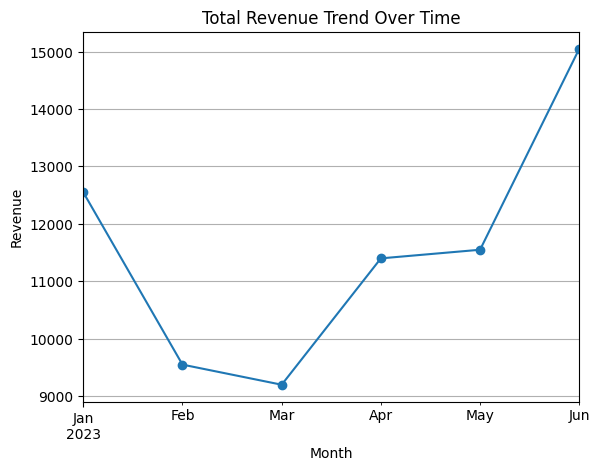

Month
Jan 2023    12550.0
Feb 2023     9550.0
Mar 2023     9200.0
Apr 2023    11400.0
May 2023    11550.0
Jun 2023    15050.0
Name: Revenue, dtype: float64


In [322]:
monthly_trend = reporting_data.groupby('Month')['Revenue'].sum()

monthly_trend.plot(kind='line', marker='o', title='Total Revenue Trend Over Time')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.grid(True)
plt.show()

monthly_trend.index = monthly_trend.index.strftime('%b %Y')
print(monthly_trend)


In [323]:
# Calculate percentage changes in revenue
monthly_growth = monthly_trend.pct_change() * 100
monthly_growth = monthly_growth.round(2)

print('Month on month growth (%) is represented below:\n',monthly_growth)

# Calculate and display data insights
largest_drop = monthly_growth.min()
largest_drop_month = monthly_growth.idxmin()

largest_increase = monthly_growth.max()
largest_increase_month = monthly_growth.idxmax()

markdown_text = f"""
The largest drop in revenue occurred in {largest_drop_month}, with a decrease of {largest_drop}%, followed by recovery in later months as seen in {largest_increase_month}, with an increase of {largest_increase}.
"""
display(Markdown(markdown_text))

Month on month growth (%) is represented below:
 Month
Jan 2023      NaN
Feb 2023   -23.90
Mar 2023    -3.66
Apr 2023    23.91
May 2023     1.32
Jun 2023    30.30
Name: Revenue, dtype: float64



The largest drop in revenue occurred in Feb 2023, with a decrease of -23.9%, followed by recovery in later months as seen in Jun 2023, with an increase of 30.3.


In [324]:
monthly_trend = reporting_data.groupby('Month')['Revenue'].sum()

monthly_growth = monthly_trend.pct_change() * 100
monthly_growth = monthly_growth.round(2)

monthly_trend_df = monthly_trend.reset_index()
monthly_trend_df.columns = ['Month', 'Revenue']

monthly_growth_df = monthly_growth.reset_index()
monthly_growth_df.columns = ['Month', 'Revenue_Growth_%']

monthly_revenue_analysis_df = pd.merge(
    monthly_trend_df,
    monthly_growth_df,
    on='Month',
    how='left'
)

monthly_revenue_analysis_df['Month'] = monthly_revenue_analysis_df['Month'].astype(str)
display(monthly_revenue_analysis_df)

,Month,Revenue,Revenue_Growth_%
0,2023-01,12550.0,NaN
1,2023-02,9550.0,-23.90
2,2023-03,9200.0,-3.66
3,2023-04,11400.0,23.91
4,2023-05,11550.0,1.32
5,2023-06,15050.0,30.30


## Profitability Analysis

In [325]:
profitability_extended = reporting_data.groupby('Company').agg(
    Mean_Profit_Margin=('Profit_Margin', 'mean'),
    Company_Region=('Region', lambda x: x.iloc[0]), # Get the first region for the company
    Mean_Revenue=('Revenue', 'mean'),
    Mean_Costs=('Costs', 'mean'),
    Mean_Profit=('Profit', 'mean')
).reset_index().sort_values(by='Mean_Profit_Margin', ascending=False)

# Round the numeric columns for better display
profitability_extended['Mean_Profit_Margin'] = profitability_extended['Mean_Profit_Margin'].round(3)
profitability_extended['Mean_Revenue'] = profitability_extended['Mean_Revenue'].round(2)
profitability_extended['Mean_Costs'] = profitability_extended['Mean_Costs'].round(2)
profitability_extended['Mean_Profit'] = profitability_extended['Mean_Profit'].round(2)

# Calculate overall mean profit from reporting_data
overall_mean_profit = reporting_data['Profit'].mean()

# Calculate the standard deviation of 'Mean_Profit' across all companies
std_dev_company_mean_profits = profitability_extended['Mean_Profit'].std()

# Add a new column for standardized deviation of company mean profit
# This calculates how many standard deviations each company's mean profit is from the overall mean profit.
profitability_extended['SD_Profit_Deviation'] = \
    ((profitability_extended['Mean_Profit'] - overall_mean_profit) / std_dev_company_mean_profits).round(2)

display(profitability_extended)

,Company,Mean_Profit_Margin,Company_Region,Mean_Revenue,Mean_Costs,Mean_Profit,SD_Profit_Deviation
1,B,0.405,GCC,1625.0,967.5,657.5,1.01
5,F,0.394,Europe,920.0,558.0,362.0,-0.97
8,I,0.378,Europe,1240.0,770.0,470.0,-0.25
7,H,0.366,GCC,1510.0,960.0,550.0,0.29
9,J,0.364,Asia,1080.0,688.0,392.0,-0.77
6,G,0.364,Asia,1840.0,1168.0,672.0,1.10
4,E,0.362,North America,2170.0,1384.0,786.0,1.87
3,D,0.352,Asia,1040.0,672.0,368.0,-0.93
2,C,0.352,Europe,1325.0,860.0,465.0,-0.28
0,A,0.328,GCC,1170.0,786.0,384.0,-0.82


In [326]:
# Extract insights dynamically from profitability_extended

# Top performer
top_performer = profitability_extended.iloc[0]
top_company = top_performer['Company']
top_profit_margin = top_performer['Mean_Profit_Margin']
top_sd_profit_deviation = top_performer['SD_Profit_Deviation']

# Bottom performer
bottom_performer = profitability_extended.iloc[-1]
bottom_company = bottom_performer['Company']
bottom_profit_margin = bottom_performer['Mean_Profit_Margin']
bottom_sd_profit_deviation = bottom_performer['SD_Profit_Deviation']

# Company E details
company_e = profitability_extended[profitability_extended['Company'] == 'E'].iloc[0]
company_e_region = company_e['Company_Region']
company_e_revenue = company_e['Mean_Revenue']
company_e_profit = company_e['Mean_Profit']
company_e_sd_profit_deviation = company_e['SD_Profit_Deviation']

profitability_commentary = f"""Based on the profitability analysis:

*   **{top_company}** leads with the highest Mean Profit Margin ({top_profit_margin}) and a significant positive deviation from the overall mean profit ({top_sd_profit_deviation} standard deviations), showing exceptional efficiency.
*   **{bottom_company}** has the lowest Mean Profit Margin ({bottom_profit_margin}), performing below average with a {bottom_sd_profit_deviation} standard deviation from the mean profit.
*   **Company E ({company_e_region})** shows the highest Mean Revenue and Profit, driven by volume, with a very high SD Profit Deviation ({company_e_sd_profit_deviation}).
"""

display(Markdown(profitability_commentary))

Based on the profitability analysis:

*   **B** leads with the highest Mean Profit Margin (0.405) and a significant positive deviation from the overall mean profit (1.01 standard deviations), showing exceptional efficiency.
*   **A** has the lowest Mean Profit Margin (0.328), performing below average with a -0.82 standard deviation from the mean profit.
*   **Company E (North America)** shows the highest Mean Revenue and Profit, driven by volume, with a very high SD Profit Deviation (1.87).


## Revenue, Profit, and Emissions Intensity Correlation Analysis


In [327]:
correlation_analysis_intro_text = """In the following table, we analyze the relationship between monthly average revenue, monthly average profit, and average emissions intensity for each company. The goal is to identify if there is a correlation between increased revenue/profit and higher emissions intensity, which could indicate potential sustainability challenges or successes."""
display(Markdown(correlation_analysis_intro_text))

In the following table, we analyze the relationship between monthly average revenue, monthly average profit, and average emissions intensity for each company. The goal is to identify if there is a correlation between increased revenue/profit and higher emissions intensity, which could indicate potential sustainability challenges or successes.

In [328]:
# Step 1: Calculate monthly sums for Revenue and Profit for each company
monthly_sums = reporting_data.groupby(['Company', 'Year', 'Month']).agg(
    Monthly_Revenue_Sum=('Revenue', 'sum'),
    Monthly_Profit_Sum=('Profit', 'sum')
).reset_index()

# Step 2: Calculate the average of these monthly sums for each company
monthly_averages_by_company = monthly_sums.groupby('Company').agg(
    Monthly_Average_Revenue=('Monthly_Revenue_Sum', 'mean'),
    Monthly_Average_Profit=('Monthly_Profit_Sum', 'mean')
).reset_index()

# Step 3: Calculate Total Emissions, Average Profit Margin, and Average Emissions Intensity directly from reporting_data
company_metrics = reporting_data.groupby('Company').agg(
    Average_Emissions=('Emissions', 'mean'),
    Average_Profit_Margin=('Profit_Margin', 'mean'),
    Average_Emissions_Intensity=('Emissions_Intensity', 'mean')
).reset_index()

# Step 4: Merge the monthly averages with the other company metrics
company_summary = pd.merge(monthly_averages_by_company, company_metrics, on='Company')

# Rounding the new averages for consistent display
company_summary['Monthly_Average_Revenue'] = round(company_summary['Monthly_Average_Revenue'], 2)
company_summary['Monthly_Average_Profit'] = round(company_summary['Monthly_Average_Profit'], 2)
company_summary['Average_Profit_Margin'] = round(company_summary['Average_Profit_Margin'], 2)
company_summary['Average_Emissions_Intensity'] = round(company_summary['Average_Emissions_Intensity'], 3)

display(company_summary[['Company', 'Monthly_Average_Revenue', 'Monthly_Average_Profit', 'Average_Profit_Margin', 'Average_Emissions', 'Average_Emissions_Intensity']])

,Company,Monthly_Average_Revenue,Monthly_Average_Profit,Average_Profit_Margin,Average_Emissions,Average_Emissions_Intensity
0,A,1170.0,384.0,0.33,58.4,0.050
1,B,1625.0,657.5,0.40,75.0,0.046
2,C,1325.0,465.0,0.35,66.0,0.050
3,D,1040.0,368.0,0.35,47.0,0.045
4,E,2170.0,786.0,0.36,98.4,0.045
5,F,920.0,362.0,0.39,35.0,0.038
6,G,1840.0,672.0,0.36,88.2,0.048
7,H,1510.0,550.0,0.37,75.4,0.050
8,I,1240.0,470.0,0.38,62.2,0.050
9,J,1080.0,392.0,0.36,51.6,0.048


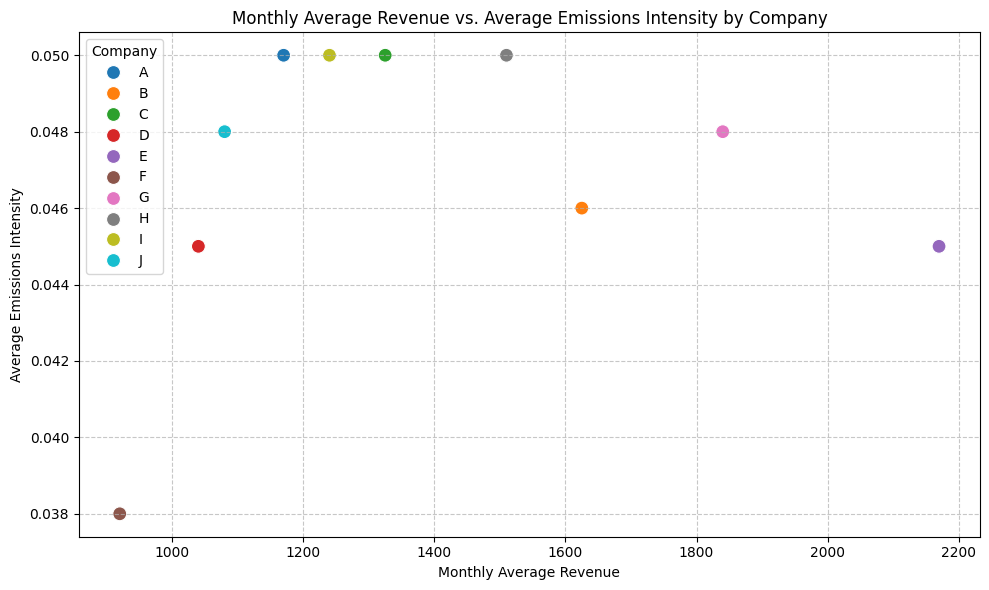

In [329]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=company_summary, x='Monthly_Average_Revenue', y='Average_Emissions_Intensity', hue='Company', s=100)
plt.title('Monthly Average Revenue vs. Average Emissions Intensity by Company')
plt.xlabel('Monthly Average Revenue')
plt.ylabel('Average Emissions Intensity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [330]:
# Simple dynamic insights for Revenue vs. Emissions Intensity scatter plot
highest_rev_co = company_summary.loc[company_summary['Monthly_Average_Revenue'].idxmax(), 'Company']
highest_intensity_co = company_summary.loc[company_summary['Average_Emissions_Intensity'].idxmax(), 'Company']

company_summary_insights = (f"Company {highest_rev_co} exhibits the highest monthly average revenue, while Company {highest_intensity_co} shows the highest average emissions intensity.\nThis scatter plot visualizes the lack of a strong direct correlation between revenue scale and emissions efficiency across the portfolio.")
display(Markdown(company_summary_insights))

Company E exhibits the highest monthly average revenue, while Company A shows the highest average emissions intensity.
This scatter plot visualizes the lack of a strong direct correlation between revenue scale and emissions efficiency across the portfolio.

## Regional Performance and Emissions Analysis

In [331]:
regional_summary = reporting_data.groupby('Region').agg(
    Mean_Regional_Revenue=('Revenue', 'mean'),
    Mean_Regional_Profit=('Profit', 'mean'),
    Mean_Regional_Emissions=('Emissions', 'mean'),
    Average_Regional_Profit_Margin=('Profit_Margin', 'mean'),
    Average_Regional_Emissions_Intensity=('Emissions_Intensity', 'mean')
).reset_index()

# Multiply the means by 6 to get the adjusted totals for a 6-month period
regional_summary['Total_Regional_Revenue'] = regional_summary['Mean_Regional_Revenue'] * 6
regional_summary['Total_Regional_Profit'] = regional_summary['Mean_Regional_Profit'] * 6
regional_summary['Total_Regional_Emissions'] = regional_summary['Mean_Regional_Emissions'] * 6

# Rounding for consistent display
regional_summary['Total_Regional_Revenue'] = round(regional_summary['Total_Regional_Revenue'], 2)
regional_summary['Total_Regional_Profit'] = round(regional_summary['Total_Regional_Profit'], 2)
regional_summary['Total_Regional_Emissions'] = round(regional_summary['Total_Regional_Emissions'], 2)
regional_summary['Average_Regional_Profit_Margin'] = round(regional_summary['Average_Regional_Profit_Margin'], 2)
regional_summary['Average_Regional_Emissions_Intensity'] = round(regional_summary['Average_Regional_Emissions_Intensity'], 3)

print('Regional Performance Summary (Adjusted Totals for 6-month period):')
display(regional_summary[['Region', 'Total_Regional_Revenue', 'Total_Regional_Profit', 'Total_Regional_Emissions', 'Average_Regional_Profit_Margin', 'Average_Regional_Emissions_Intensity']])

Regional Performance Summary (Adjusted Totals for 6-month period):


,Region,Total_Regional_Revenue,Total_Regional_Profit,Total_Regional_Emissions,Average_Regional_Profit_Margin,Average_Regional_Emissions_Intensity
0,Asia,7920.00,2864.00,373.60,0.36,0.047
1,Europe,7031.25,2606.25,330.75,0.37,0.046
2,GCC,8528.57,3128.57,415.29,0.36,0.049
3,North America,13020.00,4716.00,590.40,0.36,0.045


In [332]:
regional_performance_explanation_text = """This analysis aggregates performance and emissions data across different geographical regions. Note that total regional amounts for Revenue, Profit, and Emissions are adjusted by taking the mean of each metric per region and multiplying by 6 to represent a 6-month analysis period, rather than a direct sum. This approach accounts for removed data points and provides an average-based total. The goal is to understand regional contributions to overall revenue and profit, as well as identify regional patterns in emissions intensity."""
display(Markdown(regional_performance_explanation_text))

This analysis aggregates performance and emissions data across different geographical regions. Note that total regional amounts for Revenue, Profit, and Emissions are adjusted by taking the mean of each metric per region and multiplying by 6 to represent a 6-month analysis period, rather than a direct sum. This approach accounts for removed data points and provides an average-based total. The goal is to understand regional contributions to overall revenue and profit, as well as identify regional patterns in emissions intensity.

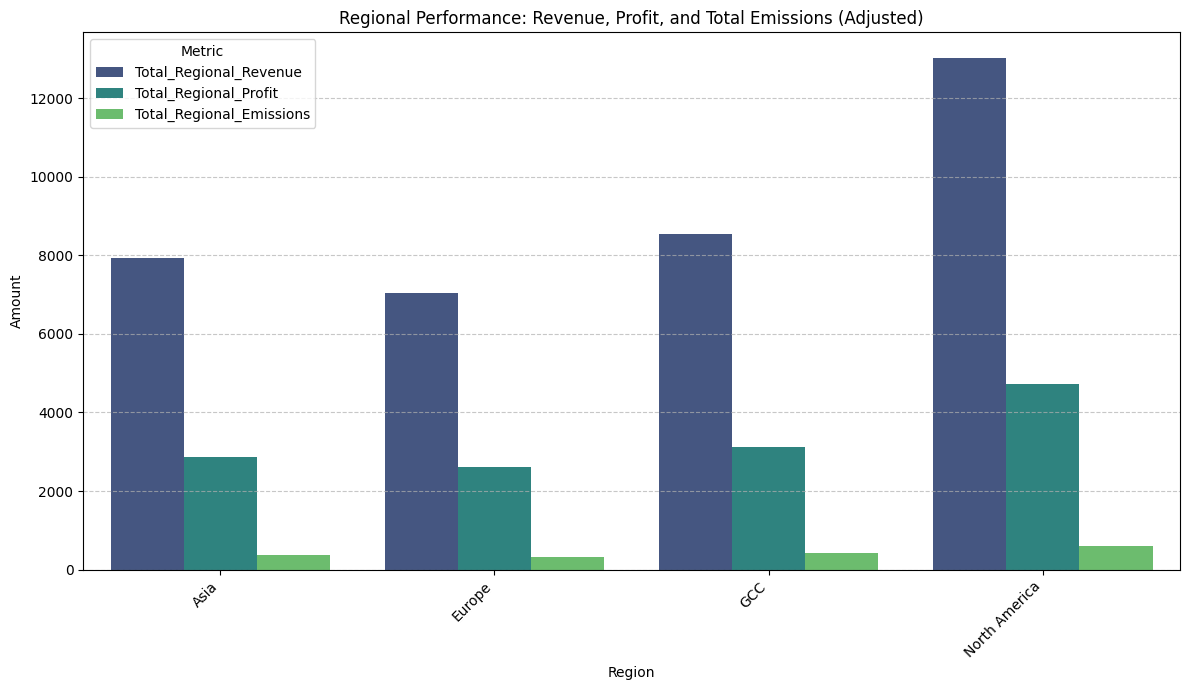

In [333]:
# Melt the regional_summary DataFrame for plotting
regional_performance_melted = regional_summary.melt(
    id_vars=['Region'],
    value_vars=['Total_Regional_Revenue', 'Total_Regional_Profit', 'Total_Regional_Emissions'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=regional_performance_melted,
    x='Region',
    y='Amount',
    hue='Metric',
    palette='viridis'
)

plt.title('Regional Performance: Revenue, Profit, and Total Emissions (Adjusted)')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [334]:
# Extract dynamic regional insights
top_rev_region = regional_summary.loc[regional_summary['Total_Regional_Revenue'].idxmax(), 'Region']
top_rev_val = regional_summary['Total_Regional_Revenue'].max()

top_profit_region = regional_summary.loc[regional_summary['Total_Regional_Profit'].idxmax(), 'Region']

bot_rev_region = regional_summary.loc[regional_summary['Total_Regional_Revenue'].idxmin(), 'Region']

avg_intensity = regional_summary['Average_Regional_Emissions_Intensity'].mean().round(3)
high_intensity_region = regional_summary.loc[regional_summary['Average_Regional_Emissions_Intensity'].idxmax(), 'Region']

regional_performance_key_takeaways_text = f"""This visualization helps in quickly identifying top-performing regions financially and in understanding their corresponding emissions levels.

* **{top_rev_region}** shows the highest adjusted total revenue ({top_rev_val}) and profit, indicating significant economic activity.

* **{bot_rev_region}** has the lowest adjusted total revenue and profit among the regions.

In terms of Average Emissions Intensity, the values are relatively close across regions (average: {avg_intensity}), with **{high_intensity_region}** having a slightly higher intensity, which might correlate with its higher overall activity."""

display(Markdown(regional_performance_key_takeaways_text))

This visualization helps in quickly identifying top-performing regions financially and in understanding their corresponding emissions levels.

* **North America** shows the highest adjusted total revenue (13020.0) and profit, indicating significant economic activity.

* **Europe** has the lowest adjusted total revenue and profit among the regions.

In terms of Average Emissions Intensity, the values are relatively close across regions (average: 0.047), with **GCC** having a slightly higher intensity, which might correlate with its higher overall activity.

## Data Quality Analysis

In [335]:
# Calculate total missing Revenue entries by Month
missing_revenue_by_month = data_quality_issues[data_quality_issues['Revenue'].isnull()].groupby('Month').size().reset_index(name='Missing_Revenue_Count')

# Calculate total missing Costs entries by Month
missing_costs_by_month = data_quality_issues[data_quality_issues['Costs'].isnull()].groupby('Month').size().reset_index(name='Missing_Costs_Count')

# Calculate total missing Emissions entries by Month
missing_emissions_by_month = data_quality_issues[data_quality_issues['Emissions'].isnull()].groupby('Month').size().reset_index(name='Missing_Emissions_Count')

print('Missing Revenue Data:')
display(missing_revenue_by_month)
print('\nMissing Costs Data:')
display(missing_costs_by_month)
print('\nMissing Emissions Data:')
display(missing_emissions_by_month)

Missing Revenue Data:


,Month,Missing_Revenue_Count



Missing Costs Data:


,Month,Missing_Costs_Count
0,2023-02,1



Missing Emissions Data:


,Month,Missing_Emissions_Count
0,2023-02,2
1,2023-03,3
2,2023-04,2
3,2023-05,2


In [336]:
# Identify rows with missing Emissions data
missing_emissions_data = data_quality_issues[data_quality_issues['Emissions'].isnull()]

# Group by Region and count the number of missing Emissions entries
missing_emissions_by_region = missing_emissions_data.groupby('Region').size().reset_index(name='Missing_Emissions_Count')

# Sort the results to see which region is missing the most data
missing_emissions_by_region_sorted = missing_emissions_by_region.sort_values(by='Missing_Emissions_Count', ascending=False)

print('Regions with the Most Missing Emissions Data:')
display(missing_emissions_by_region_sorted)

# You can further analyze the 'missing_emissions_by_region_sorted' DataFrame if needed.

Regions with the Most Missing Emissions Data:


,Region,Missing_Emissions_Count
0,Asia,3
2,GCC,3
1,Europe,2
3,North America,1


In [337]:
# Calculate missing counts for dynamic insight
missing_emissions_total = int(data_quality_issues['Emissions'].isnull().sum())
missing_costs_total = int(data_quality_issues['Costs'].isnull().sum())
missing_revenue_total = int(data_quality_issues['Revenue'].isnull().sum())

# Get top regions for missing emissions
top_missing_regions = missing_emissions_by_region_sorted.head(2)['Region'].tolist()
top_missing_count = int(missing_emissions_by_region_sorted.head(1)['Missing_Emissions_Count'].iloc[0])

data_quality_analysis_insight_text = f"Based on the data quality analysis, both {top_missing_regions[0]} and {top_missing_regions[1]} regions show the highest number of missing emissions data points, with {top_missing_count} entries each. Conversely, there are no missing revenue data points for any region and only {missing_costs_total} missing cost data point."

display(Markdown(data_quality_analysis_insight_text))

Based on the data quality analysis, both Asia and GCC regions show the highest number of missing emissions data points, with 3 entries each. Conversely, there are no missing revenue data points for any region and only 1 missing cost data point.

# Key Takeaways


In [338]:
overall_key_takeaways_text = """* Data quality issues were isolated before analysis, improving reliability of reporting outputs.\n* Missing emissions data was concentrated in Asia and GCC, suggesting where follow-up should be prioritized.\n* A repeatable workflow allows updated source data to be refreshed and reprocessed quickly."""
display(Markdown(overall_key_takeaways_text))

* Data quality issues were isolated before analysis, improving reliability of reporting outputs.
* Missing emissions data was concentrated in Asia and GCC, suggesting where follow-up should be prioritized.
* A repeatable workflow allows updated source data to be refreshed and reprocessed quickly.

# Exporting Data to Excel


In [339]:
!pip install xlsxwriter

In [340]:

excel_output_path = '/content/gdrive/MyDrive/ESG_Data_Analysis_Full.xlsx'

with pd.ExcelWriter(excel_output_path, engine='xlsxwriter') as writer:
    def write_insight_to_sheet(sheet_name, start_row, title, content):
        worksheet = writer.sheets[sheet_name]
        title_format = writer.book.add_format({'bold': True, 'font_size': 12, 'bottom': 1})
        text_format = writer.book.add_format({'font_size': 10, 'text_wrap': True})
        worksheet.write(start_row, 0, title, title_format)
        content = content.replace('**', '').replace('*', '')
        content_lines = content.split('\n')
        line_offset = 1
        for line in content_lines:
            if line.strip():
                worksheet.write(start_row + line_offset, 0, line, text_format)
            line_offset += 1
        return start_row + line_offset + 1

    # 1. Export DataFrames
    company_summary.to_excel(writer, sheet_name='Company_Summary', index=False)
    regional_summary.to_excel(writer, sheet_name='Regional_Summary', index=False)
    monthly_revenue_analysis_df.to_excel(writer, sheet_name='Monthly_Revenue_Analysis', index=False)
    profitability_extended.to_excel(writer, sheet_name='Profitability_Analysis', index=False)
    data_quality_issues.to_excel(writer, sheet_name='Data_Quality_Issues', index=False)
    reporting_data.to_excel(writer, sheet_name='Reporting_Data', index=False)

    # 2. Missing Data Summary Sheet
    missing_data_sheet = writer.book.add_worksheet('Missing_Data_Summary')
    current_row_missing = 0
    missing_revenue_by_month.to_excel(writer, sheet_name='Missing_Data_Summary', startrow=current_row_missing + 1, index=False)
    current_row_missing += len(missing_revenue_by_month) + 3
    missing_costs_by_month.to_excel(writer, sheet_name='Missing_Data_Summary', startrow=current_row_missing + 1, index=False)
    current_row_missing += len(missing_costs_by_month) + 3
    missing_emissions_by_month.to_excel(writer, sheet_name='Missing_Data_Summary', startrow=current_row_missing + 1, index=False)
    current_row_missing += len(missing_emissions_by_month) + 3
    missing_emissions_by_region_sorted.to_excel(writer, sheet_name='Missing_Data_Summary', startrow=current_row_missing + 1, index=False)

    # 3. Dynamic Commentary & Insights
    write_insight_to_sheet('Monthly_Revenue_Analysis', monthly_revenue_analysis_df.shape[0] + 2, "Revenue Trend Analysis", markdown_text)
    write_insight_to_sheet('Company_Summary', company_summary.shape[0] + 2, "Correlation Analysis", correlation_analysis_intro_text + "\n" + company_summary_insights)
    write_insight_to_sheet('Profitability_Analysis', profitability_extended.shape[0] + 2, "Profitability Analysis Commentary", profitability_commentary)
    write_insight_to_sheet('Regional_Summary', regional_summary.shape[0] + 2, "Regional Performance Key Takeaways", regional_performance_key_takeaways_text)
    write_insight_to_sheet('Data_Quality_Issues', data_quality_issues.shape[0] + 2, "Data Quality Introduction", data_quality_issues_intro_text)
    write_insight_to_sheet('Missing_Data_Summary', current_row_missing + 7, "Data Quality Analysis Insight", data_quality_analysis_insight_text)

    writer.book.add_worksheet('Overall_Key_Takeaways')
    write_insight_to_sheet('Overall_Key_Takeaways', 0, "Overall Key Takeaways", overall_key_takeaways_text)

    # 4. Attach Charts
    imgdata_rev = io.BytesIO()
    monthly_trend.plot(kind='line', marker='o')
    plt.savefig(imgdata_rev, format='png')
    plt.close()
    writer.sheets['Monthly_Revenue_Analysis'].insert_image('G2', 'rev_chart.png', {'image_data': imgdata_rev})

    imgdata_corr = io.BytesIO()
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=company_summary, x='Monthly_Average_Revenue', y='Average_Emissions_Intensity', hue='Company')
    plt.savefig(imgdata_corr, format='png')
    plt.close()
    writer.sheets['Company_Summary'].insert_image('H2', 'corr_chart.png', {'image_data': imgdata_corr})

    imgdata_reg = io.BytesIO()
    plt.figure(figsize=(10,6))
    sns.barplot(data=regional_performance_melted, x='Region', y='Amount', hue='Metric')
    plt.savefig(imgdata_reg, format='png')
    plt.close()
    writer.sheets['Regional_Summary'].insert_image('K2', 'reg_chart.png', {'image_data': imgdata_reg})

print(f"Data and charts successfully exported to '{excel_output_path}'")

Data and charts successfully exported to '/content/gdrive/MyDrive/ESG_Data_Analysis_Full.xlsx'
